# Description of this study
* This preliminary study aimed to determine the optimal integration time for the multispectral camera. To achieve this, a wall was 3D-printed under experimental conditions to observe consistent thermal activity across its structure.
* For each printed layer (from 1 to 12), the integration time of the Ximea camera was systematically adjusted.
* Following the spatial recalibration of the Ximea camera relative to the CRED camera using a homographic matrix, the area of the mushy zone—identified via the CRED camera—was analyzed using the digital levels of the Ximea. To assess sensor saturation, only the extremum channels (out of the 25 available) were selected for investigation.


# Imports

In [13]:
import os
import cv2
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from datetime import datetime
import time
from pathlib import Path

from skimage.measure import label,regionprops
from scipy import ndimage as ndi

import scienceplots
plt.style.use(['science', 'notebook', 'grid'])


from TherMIFASOL.core.variables.GlobalVariables import (
    LINES_CRED, COLUMNS_CRED, T_SOLIDUS
)

from TherMIFASOL.core.data_processing.CRED_functions import (
    dl_to_thermo
)
from TherMIFASOL.core.data_processing.XIMEA_functions import (
    load_splitted_channels_nir,
)

import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)


In [14]:
PATH_DATA = "/media/dolle/Extreme SSD/DATA_MIFASOL/"
# Work path project
try:
    BASE_DIR = Path(__file__).resolve().parents[3]
except NameError:
    BASE_DIR = Path().resolve().parents[3]


# Path to data
#-------------------
data_path = os.path.join(
    PATH_DATA, "experiences/7 AddMultiSpectral/research_IT/"
)


# Homographic matrix
#-------------------
H_matrix_path = os.path.join(BASE_DIR, "TherMIFASOL/resources/tables/homographic_matrix/")


# Calibration tables
#-------------------
##   CRED:
array_nuc = np.load(
    os.path.join(
        BASE_DIR, "TherMIFASOL/resources/tables/NUC/NUC_2pts_Temp550_WithNeutralDensity.npy"
        )
    )
array_calibration = np.load(
    os.path.join(
        BASE_DIR, "TherMIFASOL/resources/tables/FLUX/FLUX_IT40_deg1_NUC2.npy"
        )
    )
## XIMEA:
XIMEA_NUC_table = np.load(
    os.path.join(BASE_DIR, "TherMIFASOL/resources/tables/XIMEA_TRAVAIL_EMMANUEL/nuc_NUC_LURPA.npy")
)
# Flux: IT3 --> 102 µs"
XIMEA_flux_table_Poly1 = np.load(
    os.path.join(BASE_DIR, "TherMIFASOL/resources/tables/XIMEA_TRAVAIL_EMMANUEL/table_flux_IT3_afterNUC1.npy")
)  ## Poly1: Linear flux/DL relationship ---> extrapolation
XIMEA_flux_table_Poly5 = np.load(
    os.path.join(BASE_DIR, "TherMIFASOL/resources/tables/XIMEA_TRAVAIL_EMMANUEL/table_flux_IT3_afterNUC5.npy")
)  ## Poly5: flux/DL relationship ---> interpolation
Low_limit_for_switch = np.load(
    os.path.join(BASE_DIR, "TherMIFASOL/resources/tables/XIMEA_TRAVAIL_EMMANUEL/LimiteBASSE_DL.npy")
)  # Limit for switching to interpolate side to extrapolate side


# Saving path
#------------
saving_path = os.path.join(BASE_DIR, "results/AddMultiSpectral/research_IT/")

# Preliminary work

## Homographic matrix

In [15]:
with open(f'{H_matrix_path}/H_matrix.pkl', 'rb') as f:
    matrice_H = pickle.load(f)

## Introduction of a local dalay
Two hours of difference between internal clocks of the two devices. Need to be taken into consideration of temporal synchronization

In [16]:
two_hours = 2*60*60  # sec

# Local Functions

In [17]:
def get_metadata_CRED(recorded_time_path:str):
    tim_python_NIR = np.loadtxt(f'{recorded_time_path}')
    return tim_python_NIR

In [18]:
def get_metadata_XIQ(metadata_path:str, delay:float):
    
    metadata_NIR=pd.read_csv(metadata_path, encoding='unicode_escape', sep=',')
    tim_python_NIR=np.asarray(metadata_NIR['t(s)'])
    exposure=np.asarray(metadata_NIR['ExposureTime']).mean()
    id_im_NIR = np.asarray(metadata_NIR['ImageUniqueID'])

    absolute_time = np.asarray([
        time.mktime(datetime.strptime(t, "%Y:%m:%d %H:%M:%S").timetuple()) \
             for t in metadata_NIR['DateTimeOriginal']
    ]) + np.asarray(metadata_NIR['SubsecTimeOriginal']) + delay

    return tim_python_NIR, id_im_NIR, absolute_time, exposure

## Time management

In [34]:
def get_id_syncrhonize(main_path_data:str, it:int, perc_pick_img):

    # Get time recording
    ## CRED
    time_CRED_path = os.path.join(
        main_path_data, "CRED", f"CRED_recherche_IT_{it}/time.txt"
    )
    time_CRED=get_metadata_CRED(time_CRED_path)
    ## XIMEA
    time_XIMEA_path = os.path.join(
        main_path_data, "XIQ", f"XIQ_recherche_IT_{it}/metadata.csv"
    )
    time_XIQ, ID_im_XIQ, abs_time_XIQ, _ =get_metadata_XIQ(time_XIMEA_path, delay=two_hours)

    # Processing
    start_same_record=max(time_CRED[0], abs_time_XIQ[0])
    stop_same_record=min(time_CRED[-1], abs_time_XIQ[-1])
    duration_same_recording=stop_same_record-start_same_record

    relative_id_XIMEA=np.abs(
        abs_time_XIQ - (start_same_record + perc_pick_img*duration_same_recording)
        ).argmin()
    picked_time_XIMEA=abs_time_XIQ[relative_id_XIMEA]

    relative_id_CRED=np.abs(time_CRED - picked_time_XIMEA).argmin()
    picked_time_CRED=time_CRED[relative_id_CRED]

    return relative_id_CRED, relative_id_XIMEA


## ROI investigation

In [20]:
def get_mask_ROI(image:np.array, T_inf:float, T_sup:float):

    mask_mushy = (image > T_inf) & (image < T_sup)
    mask_inf = (image > T_inf-5) & (image < T_inf+5)
    mask_sup = (image > T_sup-5) & (image < T_sup+5)

    mushy = np.zeros_like(image)
    mushy_label = label(mask_mushy) 

    rps = np.asarray(regionprops(mushy_label))
    areas = np.asarray([r.area for r in rps])  # Number of pixels of the area
    idxs = np.argsort(areas)[::-1]

    flag_ind=np.argmax(areas[idxs]/areas[idxs[0]] > 0.25)

    # Merge zones with an area higher than 25% compared to the biggest area detected.
    for idx in idxs[:flag_ind+1]:
        mushy[tuple(rps[idx].coords.T)] = 1

    # Remplir les trous dans les masques
    mushy = ndi.binary_fill_holes(mushy == 1)
    y_sup_thermo, x_sup_thermo = np.where(mushy&mask_sup)
    y_inf_thermo, x_inf_thermo = np.where(mushy&mask_inf)

    return mushy, (y_sup_thermo, x_sup_thermo), (y_inf_thermo, x_inf_thermo)


In [21]:
def save_ROI_img_synchro(img_therm:np.array, mushy:np.array, XIQ_rescaled:np.array, chanel:int, T_inf:float, T_sup:float, save_path:str):

    transparent_mushy=np.ones((mushy.shape[0], mushy.shape[1], 4), dtype=int)*230
    transparent_mushy[mushy,3]=0 
    color_inf='r'
    color_sup='r'

    fig, axes = plt.subplots(1, 2)

    im1 = axes[0].imshow(img_therm, interpolation='nearest', vmin=700, vmax=1800, cmap='viridis')
    axes[0].imshow(transparent_mushy)
    # axes[0].scatter(x_liq_thermo, y_liq_thermo, c=color_inf, s=0.1, label='Borne inf.')
    # axes[0].scatter(x_sol_thermo, y_sol_thermo, c=color_sup, s=0.1, label='Borne sup.')
    #ax.scatter(x_liq_thermo, y_liq_thermo, c='b', s=1, label='Liquidus')
    axes[0].set_title('CRED')

    cbar = fig.colorbar(im1, orientation='horizontal', pad=0.1, label="température [K]")
    for value, color in zip([T_inf, T_sup], [color_inf, color_sup]):
        cbar.ax.axvline(value, color=color, linestyle='-', linewidth=2)

    im2 = axes[1].imshow(XIQ_rescaled, cmap='viridis', vmin=0, vmax=255)
    axes[1].imshow(transparent_mushy)
    axes[1].set_title(f'XiQ NIR {chanel+1}')
    cbar2 = fig.colorbar(im2, orientation='horizontal', pad=0.1, label="Niveau de gris [ADU]")
    plt.tight_layout()
    plt.savefig(save_path)
    plt.close(fig)


# Main Study

In [22]:
# Extremum channels selection
ch_max=4
ch_min=20

# Homographic matrix of extremum channels
H_max=matrice_H[ch_max]
H_min=matrice_H[ch_min]

# Definition of the ROI
T_inf=T_SOLIDUS-100
T_sup=T_SOLIDUS+20

# List of the identifiers for the different layers and then IT.
# '3_retour', '4_retour', '5_retour': out of the FoV of the camera.
it_label=[
    '1', '2', '3', '4', '5', '6', '7', '8', '9', \
    '10', '11_bis', '12'
    ]
PERC=[
    0.8, 0.5, 0.8, 0.8, 0.7, 0.8, 0.6, 0.7, \
    0.7, 0.7, 0.8, 0.8
]
my_bins=np.arange(0, 256, 5)

In [43]:
save_img = True
for it, perc in zip(it_label, PERC):

    time_CRED_path = os.path.join(
        data_path, "CRED", f"CRED_recherche_IT_{it}/time.txt"
    )
    time_CRED=get_metadata_CRED(time_CRED_path)
    
    time_XIMEA_path = os.path.join(
        data_path, "XIQ", f"XIQ_recherche_IT_{it}/metadata.csv"
    )
    t_NIR, id_NIR, time_XIQ, exposure=get_metadata_XIQ(time_XIMEA_path, delay=two_hours)

    # Synchronization des données et récupération du meilleur candidat
    id_CRED, id_XIQ = get_id_syncrhonize(
        main_path_data=data_path, 
        it=it, 
        perc_pick_img=perc
    )

    # Chargement des images associées
    im_CRED=np.load(f'{data_path}/CRED/CRED_recherche_IT_{it}/data/im_{id_CRED}.npy')
    im_XIQ=load_splitted_channels_nir(
        frame_path=f"{data_path}/XIQ/XIQ_recherche_IT_{it}/{id_NIR[id_XIQ]:06d}_{t_NIR[id_XIQ]:.3f}.npy"
    )
    
    # Recalage des images aux canaux extremes
    img_max_rescaled=cv2.warpPerspective(im_XIQ[ch_max], H_max, (COLUMNS_CRED, LINES_CRED))
    img_min_rescaled=cv2.warpPerspective(im_XIQ[ch_min], H_min, (COLUMNS_CRED, LINES_CRED))

    # Calcul de la carte thermique
    thermo_CRED=dl_to_thermo(
        dl_raw=im_CRED.astype(float),
        nuc_table=array_nuc,
        calibration_table=array_calibration,
        emissivity=0.32
    )

    # Repérage de la zone d'interet.
    mask_ROI, *reste = get_mask_ROI(thermo_CRED, T_inf, T_sup)
    if save_img:
        save_ROI_img_synchro(
            img_therm=thermo_CRED, 
            mushy=mask_ROI, 
            XIQ_rescaled=img_max_rescaled, 
            chanel=ch_max,
            T_inf=T_inf,
            T_sup=T_sup,
            save_path=f'{saving_path}/ROI_histogramme/{it}_max.png'
            )
        save_ROI_img_synchro(
            img_therm=thermo_CRED, 
            mushy=mask_ROI, 
            XIQ_rescaled=img_min_rescaled, 
            chanel=ch_min,
            T_inf=T_inf,
            T_sup=T_sup,
            save_path=f'{saving_path}/ROI_histogramme/{it}_min.png'
            )

    hist, bins = np.histogram(img_min_rescaled[mask_ROI], bins=my_bins)
    np.save(f"{saving_path}/histogrammes/{it}_values_{ch_min}", hist)
    hist, bins = np.histogram(img_max_rescaled[mask_ROI], bins=my_bins)
    np.save(f"{saving_path}/histogrammes/{it}_values_{ch_max}", hist)

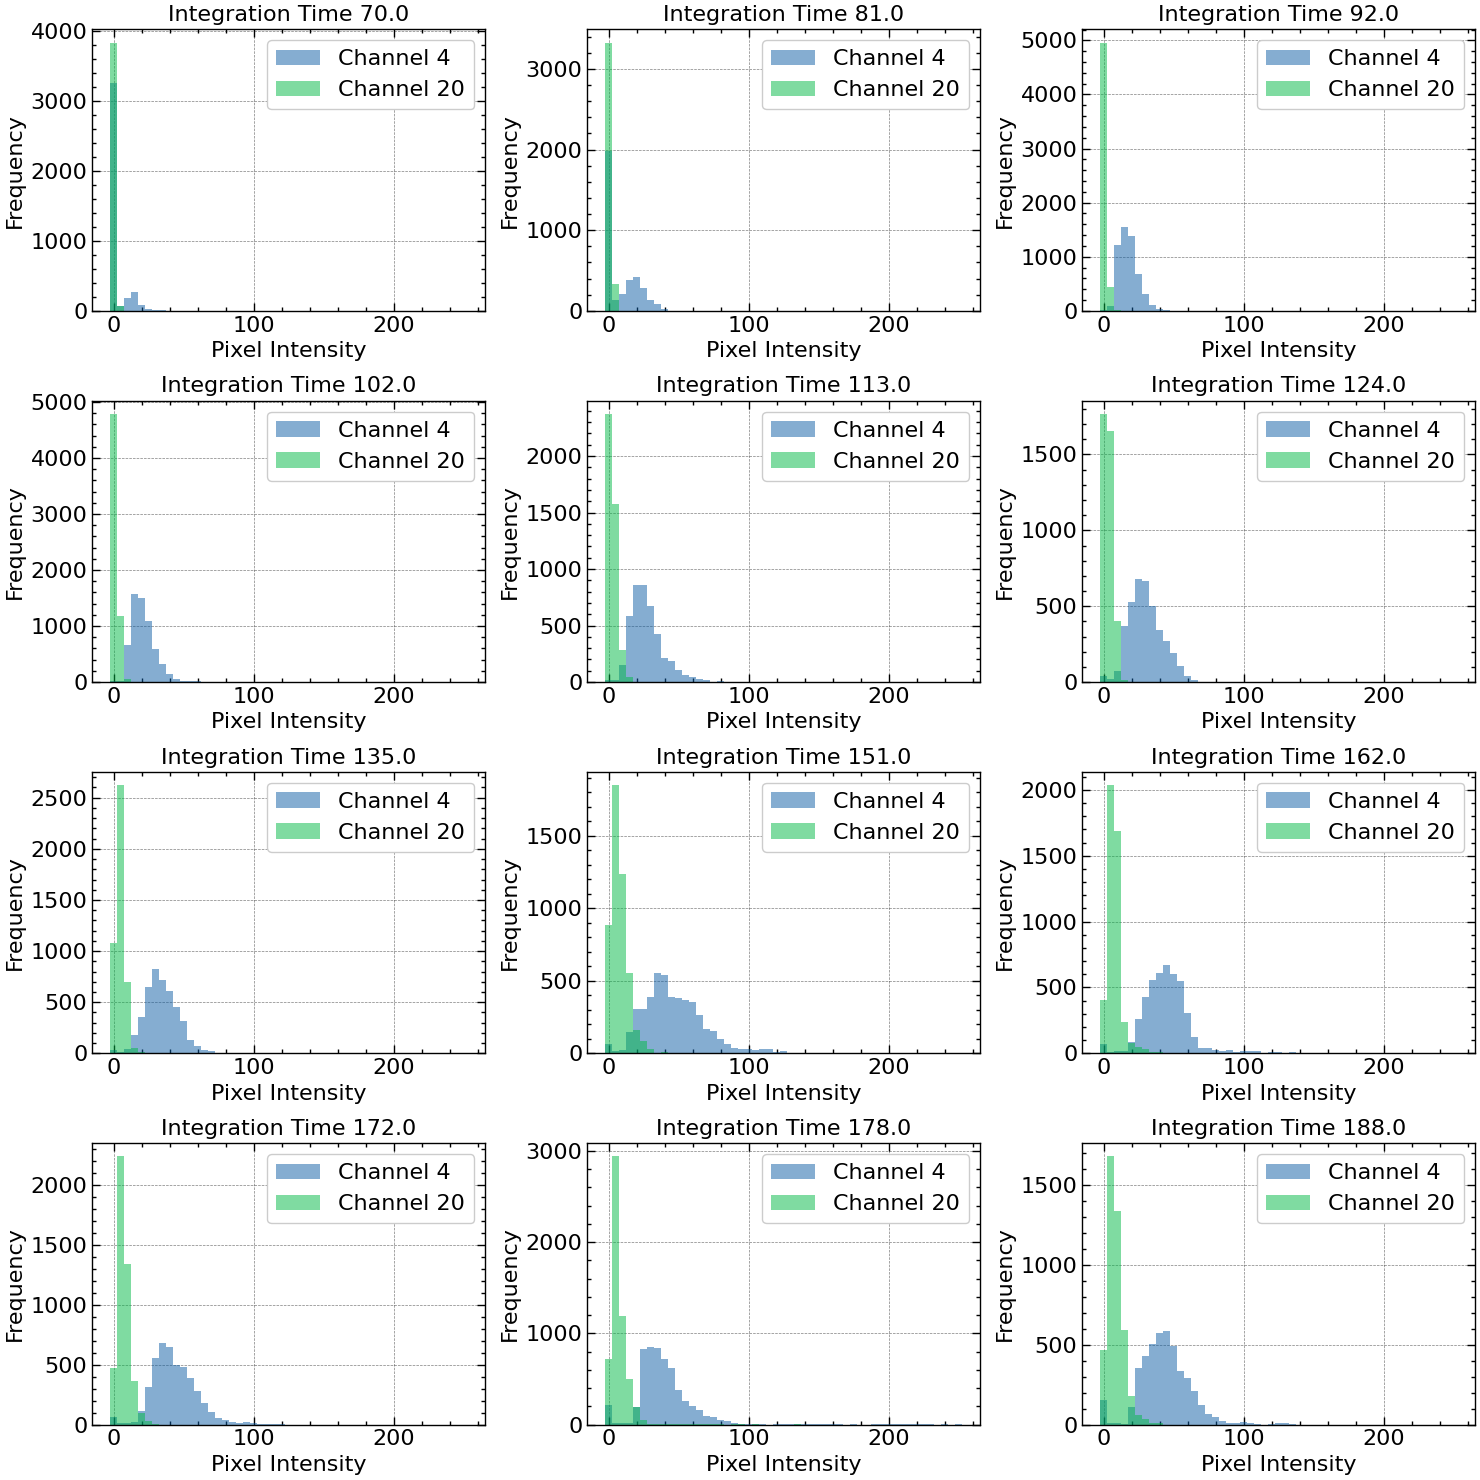

In [44]:
# Initialize the figure and axes
fig, axs = plt.subplots(nrows=4, ncols=3, figsize=(15, 15))
axs = axs.flatten()

for i, it in enumerate(it_label):

    time_XIMEA_path = os.path.join(
        data_path, "XIQ", f"XIQ_recherche_IT_{it}/metadata.csv"
    )
    *_, it_value=get_metadata_XIQ(time_XIMEA_path, delay=two_hours)
    # Load the histogram data for channel 4 and 20
    hist_4 = np.load(os.path.join(f"{saving_path}/histogrammes/", f"{it}_values_4.npy"))
    hist_20 = np.load(os.path.join(f"{saving_path}/histogrammes/", f"{it}_values_20.npy"))

    # Plot the histograms on the same graph
    axs[i].bar(my_bins[:-1], hist_4, width=np.diff(my_bins), alpha=0.5, label='Channel 4')
    axs[i].bar(my_bins[:-1], hist_20, width=np.diff(my_bins), alpha=0.5, label='Channel 20')
    
    # Set the title and labels
    axs[i].set_title(f"Integration Time {it_value}")
    axs[i].set_xlabel("Pixel Intensity")
    axs[i].set_ylabel("Frequency")
    axs[i].legend()

# Adjust the layout
plt.tight_layout()
plt.show()